# Character MLP: implementation and controlled experiments

The model maps a fixed character context to learned embeddings, concatenates them, applies a hidden activation, and predicts the next character with softmax logits. The model and SGD/Adam updates are explicit in `makemore.py`; PyTorch supplies automatic differentiation.

This notebook uses the corrected split and random-number protocol. It loads the included **10,000-update pilot**, or can rerun that pilot after changing a single flag. The pilot is not a replacement for the proposed longer study. No cell evaluates the test partition.

In [1]:
from datetime import datetime, timezone
from dataclasses import replace
import json
import math
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
from makemore import (ROOT, Config, MLP, Optimizer, load_corpus, diagnostics,
                      evaluate, load_model, sample_names)
from experiments import make_plan, run_study, paired_summaries

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
corpus = load_corpus(ROOT / 'names.txt', split_seed=42)
print('Split:', corpus.manifest['split_id'])
print(corpus.manifest['counts'])
for left, right in [(corpus.train, corpus.dev), (corpus.train, corpus.test), (corpus.dev, corpus.test)]:
    assert not (set(left) & set(right))

Split: 4fecfca583736680f3ffdad4f5271a5405e8e6e76ed0096f6786c3d4fe5e8944
{'train': {'records': 25640, 'unique_names': 23595, 'targets': 182666}, 'dev': {'records': 3196, 'unique_names': 2949, 'targets': 22801}, 'test': {'records': 3197, 'unique_names': 2950, 'targets': 22679}}


## The forward pass and training machinery

With context length three, embedding dimension ten and hidden width 200, a batch of contexts has shape `(batch, 3)`. Embedding lookup produces `(batch, 3, 10)`, concatenation gives `(batch, 30)`, the hidden layer gives `(batch, 200)`, and output logits have shape `(batch, 27)`.

A learned blend uses one coefficient per hidden neuron. Its activation is $f(z)=\alpha\tanh(z)+(1-\alpha)\operatorname{ReLU}(z)$, where $\alpha=\operatorname{sigmoid}(a)$ and the raw parameter $a$ is trained with the weights.

In [2]:
demo_config = Config(activation='blend', initialization='scaled', steps=10, decay_step=5)
model = MLP(demo_config, len(corpus.chars))
Xtr, Ytr = corpus.examples('train', demo_config.block_size)
X = Xtr[:4]
embedded = model.tensors['C'][X]
print('Contexts:', tuple(X.shape))
print('Embeddings:', tuple(embedded.shape))
print('Concatenated:', tuple(embedded.reshape(len(X), -1).shape))
print('Hidden pre-activation:', tuple(model.preactivation(X).shape))
print('Logits:', tuple(model(X).shape))
print('Parameters:', sum(p.numel() for p in model.parameters()))

Contexts: (4, 3)
Embeddings: (4, 3, 10)
Concatenated: (4, 30)
Hidden pre-activation: (4, 200)
Logits: (4, 27)
Parameters: 12097


In [3]:
# One update on a demonstration model. Experiment runs always create fresh models.
loss = F.cross_entropy(model(X), Ytr[:4])
model.zero_grad()
loss.backward()
print('Before update: minibatch NLL', loss.item())
print('Blend gradient norm:', model.tensors['alpha_raw'].grad.norm().item())
optimizer = Optimizer(model.parameters(), demo_config)
optimizer.step(demo_config.lr_at(0))
print('After update: minibatch NLL', F.cross_entropy(model(X), Ytr[:4]).item())

Before update: minibatch NLL 3.299267530441284
Blend gradient norm: 0.000976898823864758
After update: minibatch NLL 0.4693642258644104


## Randomness and initialisation

Named generators separate each shared parameter tensor, the optional blend parameters, minibatches, and sampling. At a fixed seed and context, tanh and blend begin with identical shared parameters and receive identical minibatch indices. When context width changes, identical-shaped tensors still share their initial values; the differently shaped input matrix is not claimed to be identical.

The scaled initialisation uses a fixed tanh-oriented hidden gain for both activation choices, zero biases, and small output weights. It is a controlled reference initialisation, not a claim that one scaling is optimal for every activation. Near-zero output logits should give initial NLL close to $\log(27)\approx3.296$.

In [4]:
unscaled = MLP(replace(demo_config, activation='tanh', initialization='unscaled'), len(corpus.chars))
scaled = MLP(replace(demo_config, activation='tanh', initialization='scaled'), len(corpus.chars))
Xdev, Ydev = corpus.examples('dev', 3)
for name, candidate in [('unscaled', unscaled), ('scaled', scaled)]:
    print(name, 'initial dev NLL:', evaluate(candidate, (Xdev, Ydev)))
    print(diagnostics(candidate, Xtr[:2048]))

unscaled initial dev NLL: 26.361886026106312
{'examples': 2048, 'preactivation_mean': -0.14452584087848663, 'preactivation_std': 5.703819751739502, 'tanh_derivative_mean': 0.13298606872558594, 'tanh_saturated_fraction_abs_gt_0.99': 0.6475268602371216, 'logit_std': 12.52971363067627}
scaled initial dev NLL: 3.2957639518962982
{'examples': 2048, 'preactivation_mean': -0.03264794498682022, 'preactivation_std': 1.6989692449569702, 'tanh_derivative_mean': 0.416543185710907, 'tanh_saturated_fraction_abs_gt_0.99': 0.12094726413488388, 'logit_std': 0.007064327131956816}


## Frozen pilot protocol

The pilot is a factorial comparison: two context lengths, two activations, two initialisations, three seeds, and 10,000 updates per run. All runs decay after 5,000 updates and evaluate dev every 1,000 updates. Configuration and split files are written before training begins.

Hypotheses: scaled initialisation reduces tanh saturation and improves early optimisation; any blend advantage under unscaled initialisation may shrink after scaling. A short pilot can challenge these explanations but does not establish long-budget behaviour. For the later 200k-update study, freeze its protocol before observing its outcomes.

In [5]:
RUN_TRAINING = False
STUDY_DIR = ROOT / 'results' / 'initialization-pilot'

if RUN_TRAINING:
    stamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
    STUDY_DIR = ROOT / 'results' / 'local' / f'initialization-{stamp}'
    plan = make_plan('initialization', steps=10000, seeds=[0, 1, 2], eval_every=1000)
    results = run_study(plan, corpus, STUDY_DIR, suite='initialization')
else:
    files = sorted(STUDY_DIR.glob('*/result.json'))
    if not files:
        raise FileNotFoundError('Included pilot is missing; set RUN_TRAINING=True to regenerate it.')
    results = {p.parent.name: json.loads(p.read_text()) for p in files}

assert all(r['split_id'] == corpus.manifest['split_id'] for r in results.values())
print('Loaded', len(results), 'train/dev runs from', STUDY_DIR.relative_to(ROOT))
display(Markdown((STUDY_DIR / 'README.md').read_text()))

Loaded 24 train/dev runs from results/initialization-pilot


<IPython.core.display.Markdown object>

## Per-seed differences and uncertainty

For each matched seed, define $D_s=L_{\mathrm{blend},s}-L_{\mathrm{tanh},s}$. A negative value favours the blend. Report the differences, their mean, sample standard deviation, and standard error $s_D/\sqrt n$.

With three seeds these are descriptive pilot summaries. They concern seed variation conditional on this fixed split, budget and tuning protocol. They do not quantify data-split uncertainty, remove selection effects, or provide a universal significance threshold.

context=3, init=scaled, updates=10000
  seed 0: blend - tanh = +0.003159
  seed 1: blend - tanh = +0.008830
  seed 2: blend - tanh = +0.006526
  mean: 0.006171618592203683 SD: 0.002851934252403382 SE: 0.0016465650083362067
context=4, init=scaled, updates=10000
  seed 0: blend - tanh = +0.004518
  seed 1: blend - tanh = +0.006440
  seed 2: blend - tanh = +0.003811
  mean: 0.0049230225533783605 SD: 0.001360289677808443 SE: 0.0007853636116585739
context=3, init=unscaled, updates=10000
  seed 0: blend - tanh = -0.067953
  seed 1: blend - tanh = -0.045500
  seed 2: blend - tanh = -0.093674
  mean: -0.06904260326895395 SD: 0.02410541669395071 SE: 0.013917268817180542
context=4, init=unscaled, updates=10000
  seed 0: blend - tanh = -0.084930
  seed 1: blend - tanh = -0.070485
  seed 2: blend - tanh = -0.071936
  mean: -0.07578355138846238 SD: 0.007954033448798041 SE: 0.004592263352806837


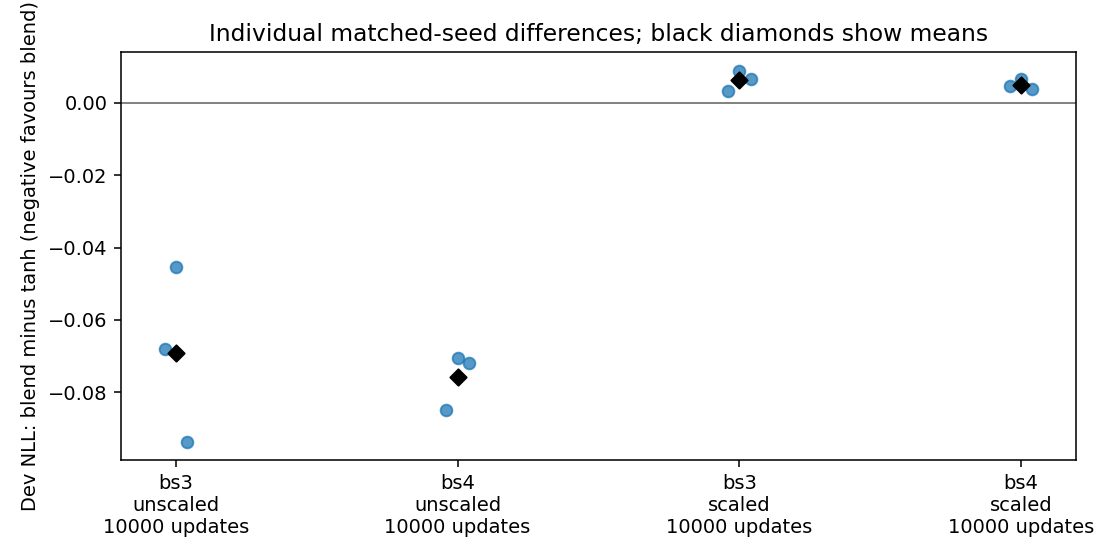

In [6]:
comparisons = paired_summaries(results)
for comparison in comparisons:
    c = comparison['protocol']['config']
    print(f"context={c['block_size']}, init={c['initialization']}, updates={c['steps']}")
    for pair in comparison['pairs']:
        print(f"  seed {pair['seed']}: blend - tanh = {pair['difference_blend_minus_tanh']:+.6f}")
    print('  mean:', comparison['mean_difference'], 'SD:', comparison['sample_sd'],
          'SE:', comparison['standard_error'])
display(Image(filename=str(STUDY_DIR / 'paired_differences.png')))

## Validation curves and compute

The four panels compare tanh and blend separately for each initialisation and context length. Lines show seed means; shading is the observed seed range, not a confidence interval. The dotted line marks learning-rate decay. Curves start at the first post-update evaluation so the large step-zero losses do not flatten them; full histories remain in the saved JSON. Vertical scales are shared within each initialisation.

[Per-seed timing curves](results/initialization-pilot/dev_by_time.png) use the measured timestamps, including dev evaluations. Time-to-target is the first observed threshold crossing, not a claim of sustained attainment.

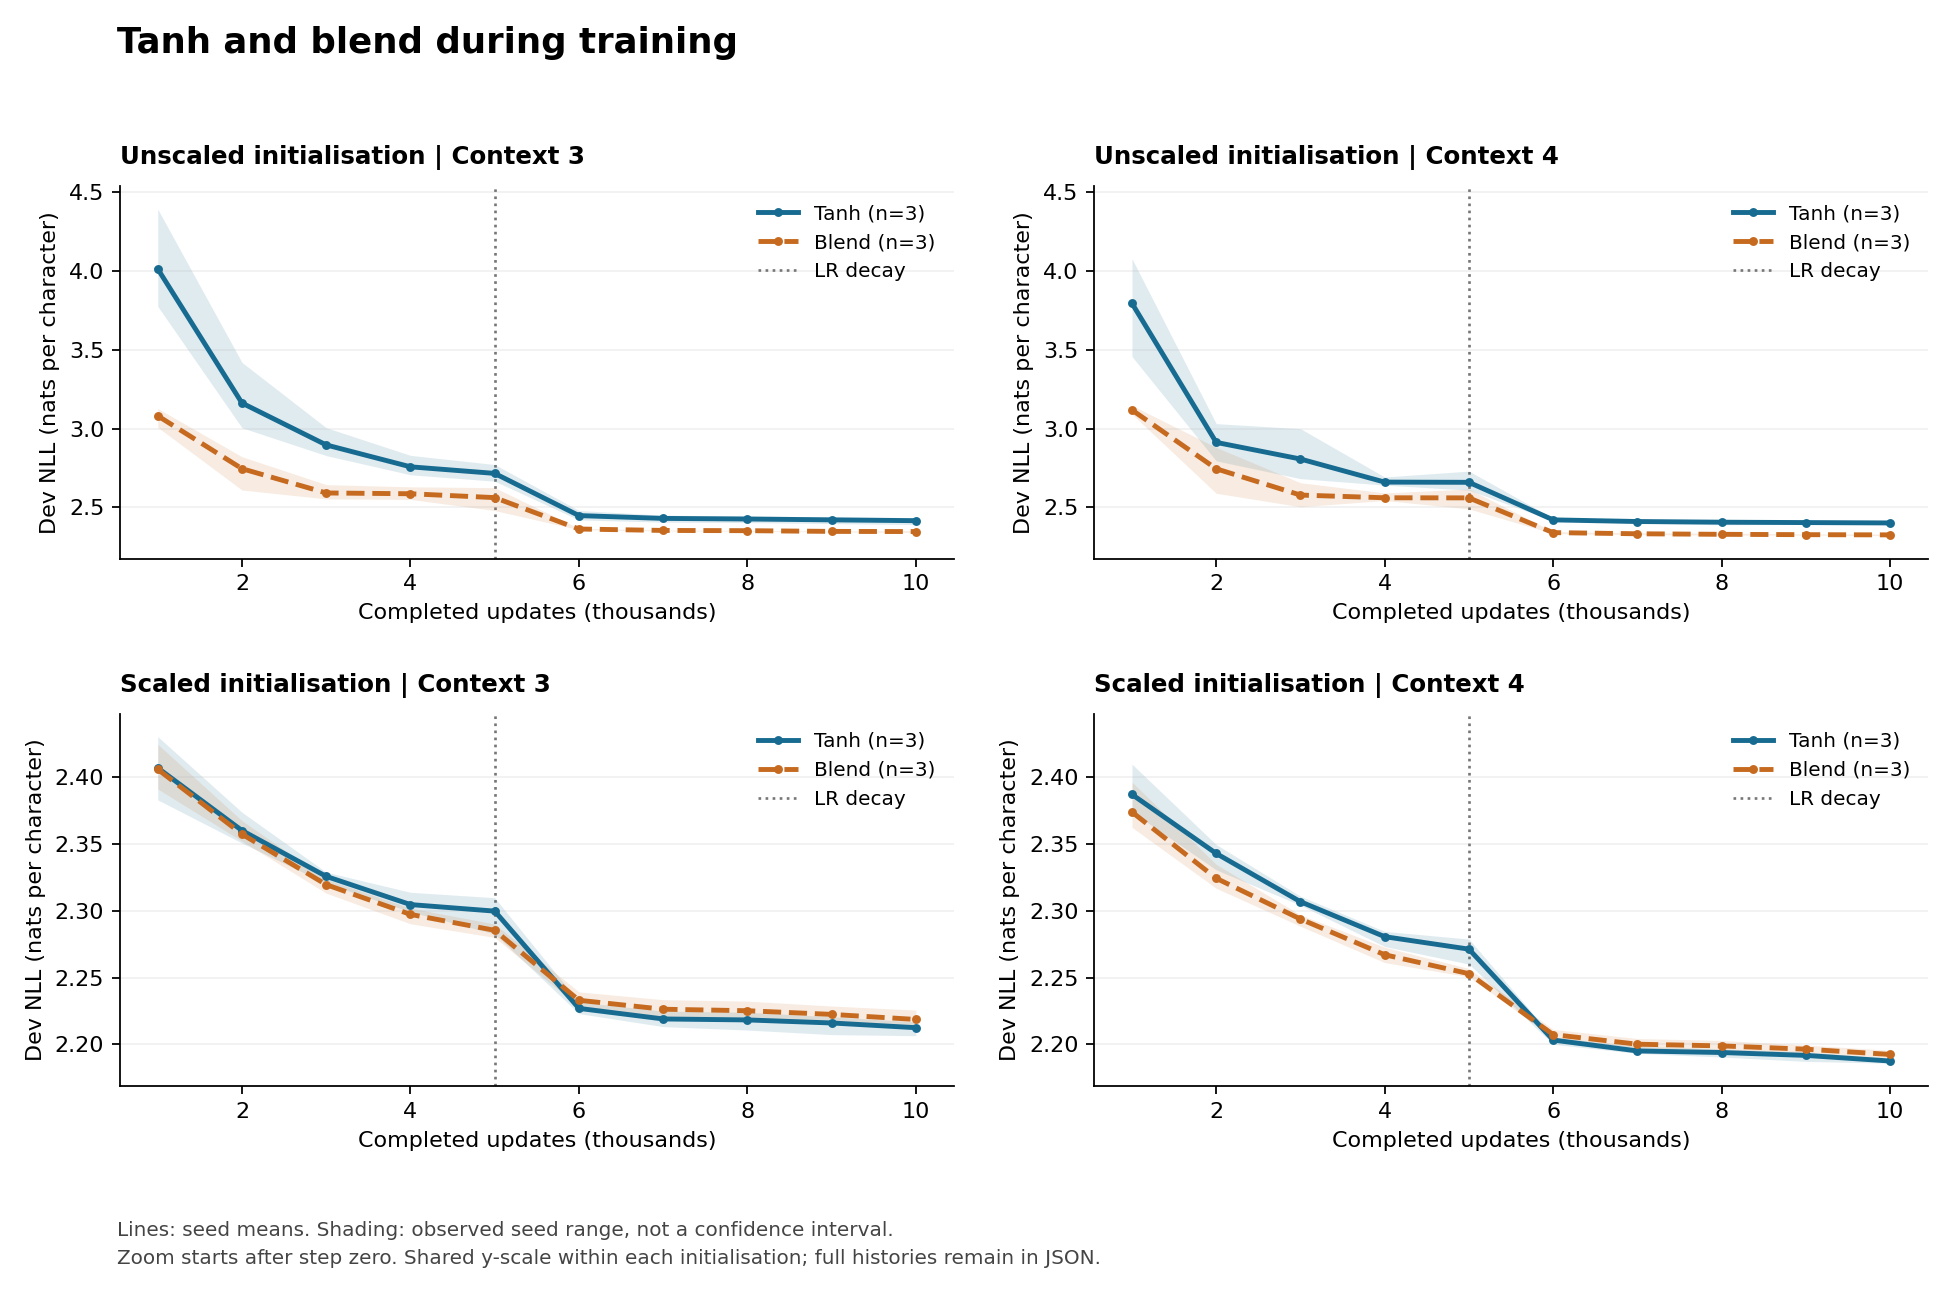

In [7]:
display(Image(filename=str(STUDY_DIR / 'dev_by_updates.png')))

## Saturation measurements

The saturation statistic is the fraction of measured pre-activation values whose tanh magnitude exceeds 0.99. It is measured on the same fixed training diagnostic subset. A difference in this statistic is an observation; establishing a causal explanation requires the initialisation intervention and the corresponding loss/gradient evidence.

In [8]:
for initialization in ['unscaled', 'scaled']:
    for context in [3, 4]:
        subset = [r for r in results.values() if r['config']['initialization'] == initialization
                  and r['config']['block_size'] == context and r['config']['activation'] == 'tanh']
        values = [r['initial_diagnostics']['tanh_saturated_fraction_abs_gt_0.99'] for r in subset]
        print(initialization, 'context', context, 'initial saturation by seed:',
              [round(v, 4) for v in values], 'mean:', sum(values) / len(values))

unscaled context 3 initial saturation by seed: [0.6475, 0.6145, 0.666] mean: 0.6426717042922974
unscaled context 4 initial saturation by seed: [0.6941, 0.6621, 0.6999] mean: 0.6853775978088379
scaled context 3 initial saturation by seed: [0.1209, 0.083, 0.1519] mean: 0.11861083656549454
scaled context 4 initial saturation by seed: [0.1183, 0.0855, 0.1454] mean: 0.11639485508203506


## Sample from a saved checkpoint

The checkpoint identifies the exact configuration and data split. These samples use a fixed sampling seed and are illustrative; no test partition is read.

In [9]:
sample_model, metadata = load_model(STUDY_DIR / 'scaled-bs3-tanh-s0' / 'model.pt')
assert metadata['split_id'] == corpus.manifest['split_id']
for sample in sample_names(sample_model, metadata['vocabulary'], n=10, seed=123):
    print(sample['name'], '' if sample['terminated'] else '[truncated]')

grets 
el 
adriel 
diai 
azexvandele 
aretariogel 
salian 
iliah 
tob 
emender 


## Longer studies and final testing

Use `experiments.py` for fixed-budget matched comparisons, the initialisation factorial study, optimiser/schedule controls and decay timing. The README gives complete commands and expected run counts.

The historical 2.0877 dev result used the old record split, seed coupling and training budget; it is archived under `docs/legacy-study.md` and is not a current-protocol result. Its reported 2.1320 test score belonged to a different model, the tanh baseline.

After all dev-based selection is complete, explicitly choose a checkpoint and use the separate `experiments.py test` command. Test evaluation is absent from the default training function and from notebook Run All. The CLI refuses to overwrite an existing test report, but no code guard can substitute for avoiding repeated test-guided selection.